<a href="https://colab.research.google.com/github/APMAPM1/Heart-Disease-Prediction/blob/Heart_disease/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Heart Disease Prediction**

* Age

* Sex :
male : 1
female : 0

* chest pain type
 - Value 1: typical angina
 - Value 2: atypical angina
 - Value 3: non-anginal pain
 - Value 4: asymptomatic

* resting blood pressure (in mm Hg on admission to the hospital)

* serum cholestoral: in mg/dl

* fasting_blood_sugar: (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)

* resting electrocardiographic results
 - Value 0: normal
 - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
 - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* thalach: maximum heart rate achieved

* exercise induced angina (1 = yes; 0 = no)
Angina is chest pain or discomfort caused when your heart muscle doesn't get enough oxygen-rich blood.
It may feel like pressure or squeezing in your chest.

* oldpeak = ST depression induced by exercise relative to rest

* slope: the slope of the peak exercise ST segment
 - Value 1: upsloping
 - Value 2: flat
 - Value 3: downsloping

* vessels colored by flourosopy : number of major vessels (0-3) colored by flourosopy

* A blood disorder called thalassemia (3 = normal; 6 = fixed defect; 7 = reversable defect)

* Target : 0 No Heart disease
1 Heart disease

# **Loading Dataset and data collection**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
from google.colab import drive

In [28]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
file_path = '/content/drive/MyDrive/Datasets/HeartDiseaseTrain-Test.csv'

In [30]:
df = pd.read_csv(file_path)
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [31]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='object')

In [32]:
df.shape

(1025, 14)

In [33]:
df.describe()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.513171
std,9.072290,17.516718,51.59251,23.005724,1.175053,0.500070
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,1.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,1.000000


In [34]:
df.describe(include=['object'])

,sex,chest_pain_type,fasting_blood_sugar,rest_ecg,exercise_induced_angina,slope,vessels_colored_by_flourosopy,thalassemia
count,1025,1025,1025,1025,1025,1025,1025,1025
unique,2,4,2,3,2,3,5,4
top,Male,Typical angina,Lower than 120 mg/ml,ST-T wave abnormality,No,Flat,Zero,Fixed Defect
freq,713,497,872,513,680,482,578,544


In [35]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [37]:
df.nunique()

,0
age,41
sex,2
chest_pain_type,4
resting_blood_pressure,49
cholestoral,152
fasting_blood_sugar,2
rest_ecg,3
Max_heart_rate,91
exercise_induced_angina,2
oldpeak,40


# **Data cleaning and Preprocessing**

## **Preprocessing**

In [38]:
df['sex'] = df['sex'].map({'Male':0, 'Female':1})

In [39]:
df['chest_pain_type'] = df['chest_pain_type'].map({'Typical angina':0, 'Atypical angina':1, 'Non-anginal pain':2, 'Asymptomatic':3})

In [40]:
df['fasting_blood_sugar'] = df['fasting_blood_sugar'].map({'Lower than 120 mg/ml':0, 'Greater than 120 mg/ml':1})

In [41]:
df['rest_ecg'] = df['rest_ecg'].map({'Normal':0, 'ST-T wave abnormality':1, 'Left ventricular hypertrophy':2})

In [42]:
df['exercise_induced_angina'] = df['exercise_induced_angina'].map({'No':0, 'Yes':1})

In [43]:
df['slope'] = df['slope'].map({'Upsloping':0, 'Flat':1, 'Downsloping':2})

In [44]:
df['vessels_colored_by_flourosopy'] = df['vessels_colored_by_flourosopy'].map({'Zero':0, 'One':1, 'Two':2, 'Three':3, 'Four':4})

In [45]:
df['thalassemia'] = df['thalassemia'].map({'Normal':0, 'Fixed Defect':1, 'Reversable Defect':2, 'No':3})

In [46]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,0,0,125,212,0,1,168,0,1.0,2,2,2,0
1,53,0,0,140,203,1,0,155,1,3.1,0,0,2,0
2,70,0,0,145,174,0,1,125,1,2.6,0,0,2,0
3,61,0,0,148,203,0,1,161,0,0.0,2,1,2,0
4,62,1,0,138,294,1,1,106,0,1.9,1,3,1,0


## **Overall features insights**

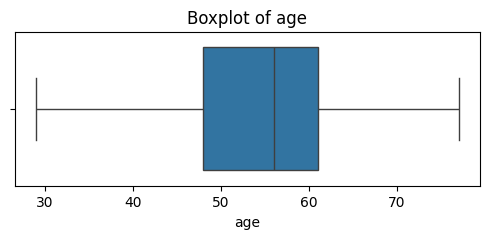

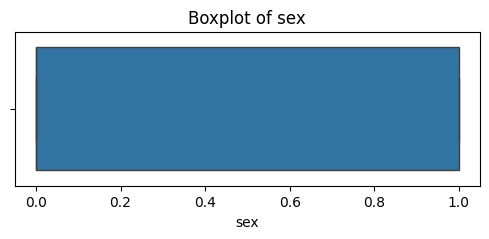

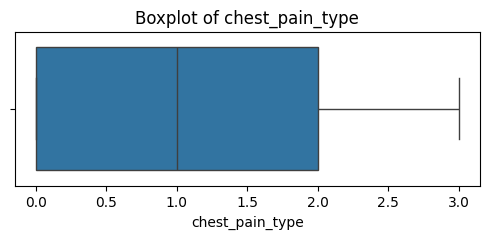

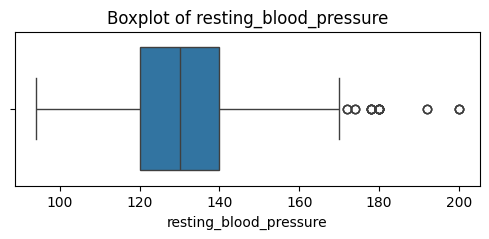

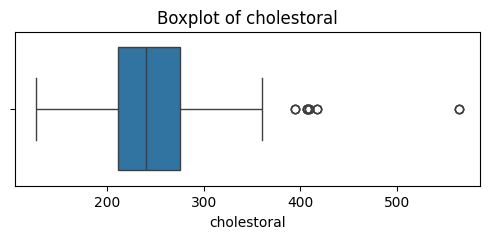

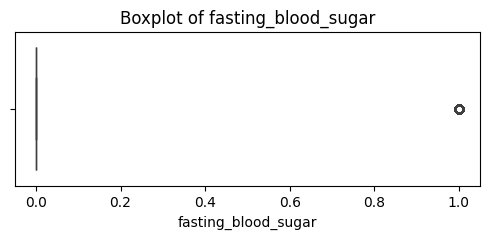

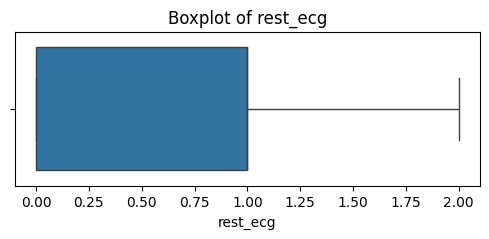

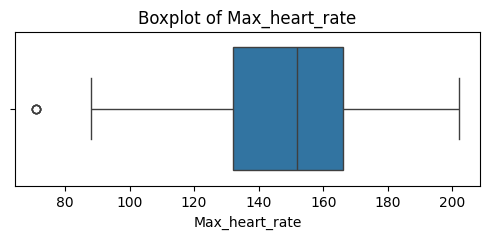

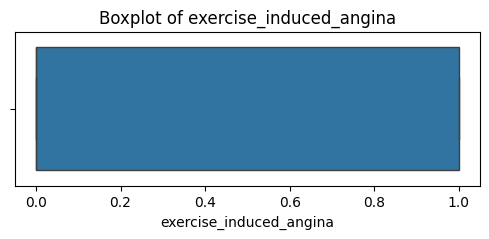

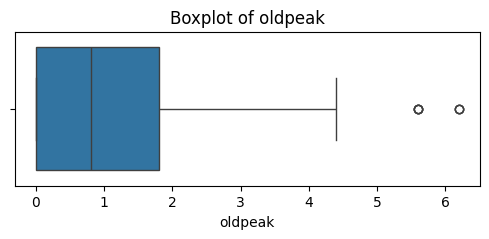

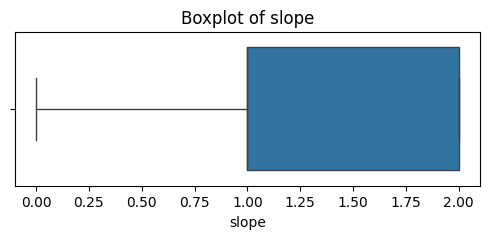

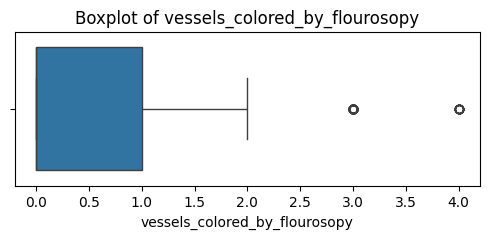

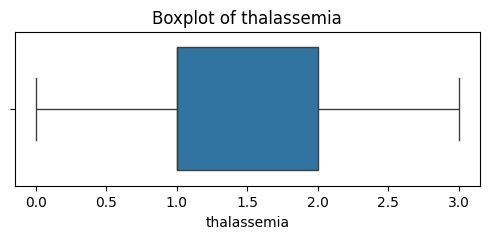

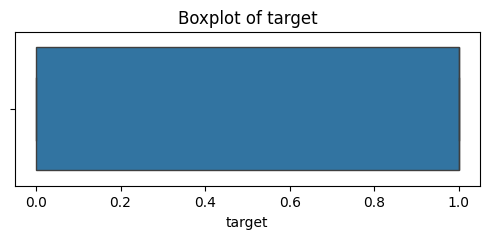

In [47]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
for col in numerical_cols:
  plt.figure(figsize=(6, 2))
  sns.boxplot(x=df[col])  # Swapped x and y for proper visualization
  plt.title(f"Boxplot of {col}")
  plt.show()

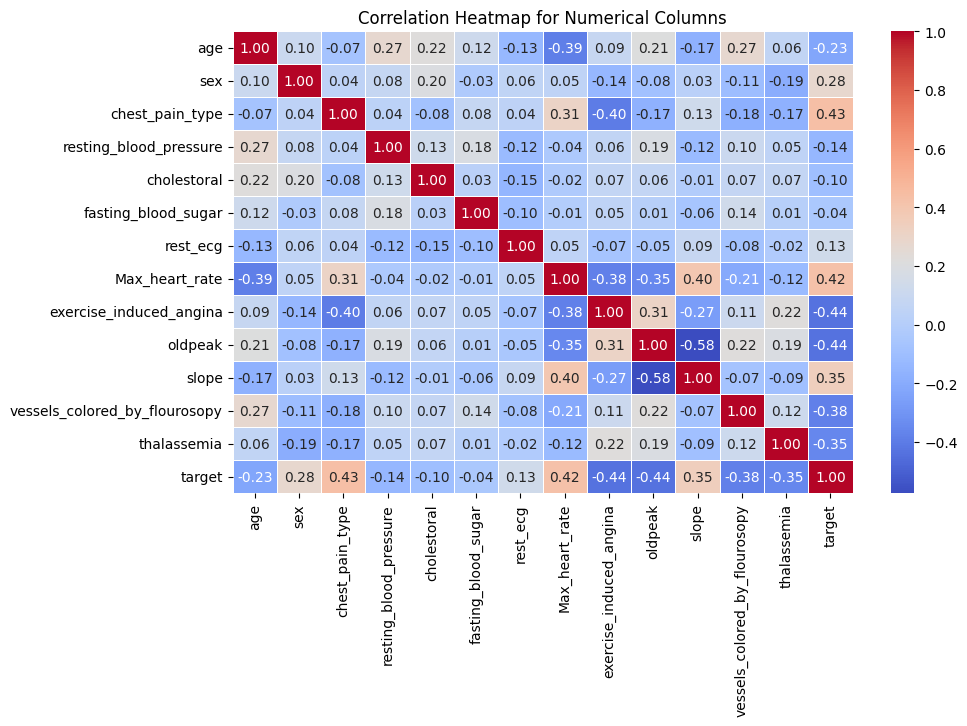

In [48]:
plt.figure(figsize=(10, 6))
# Select the numerical data, not just the column names
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Columns")
plt.show()

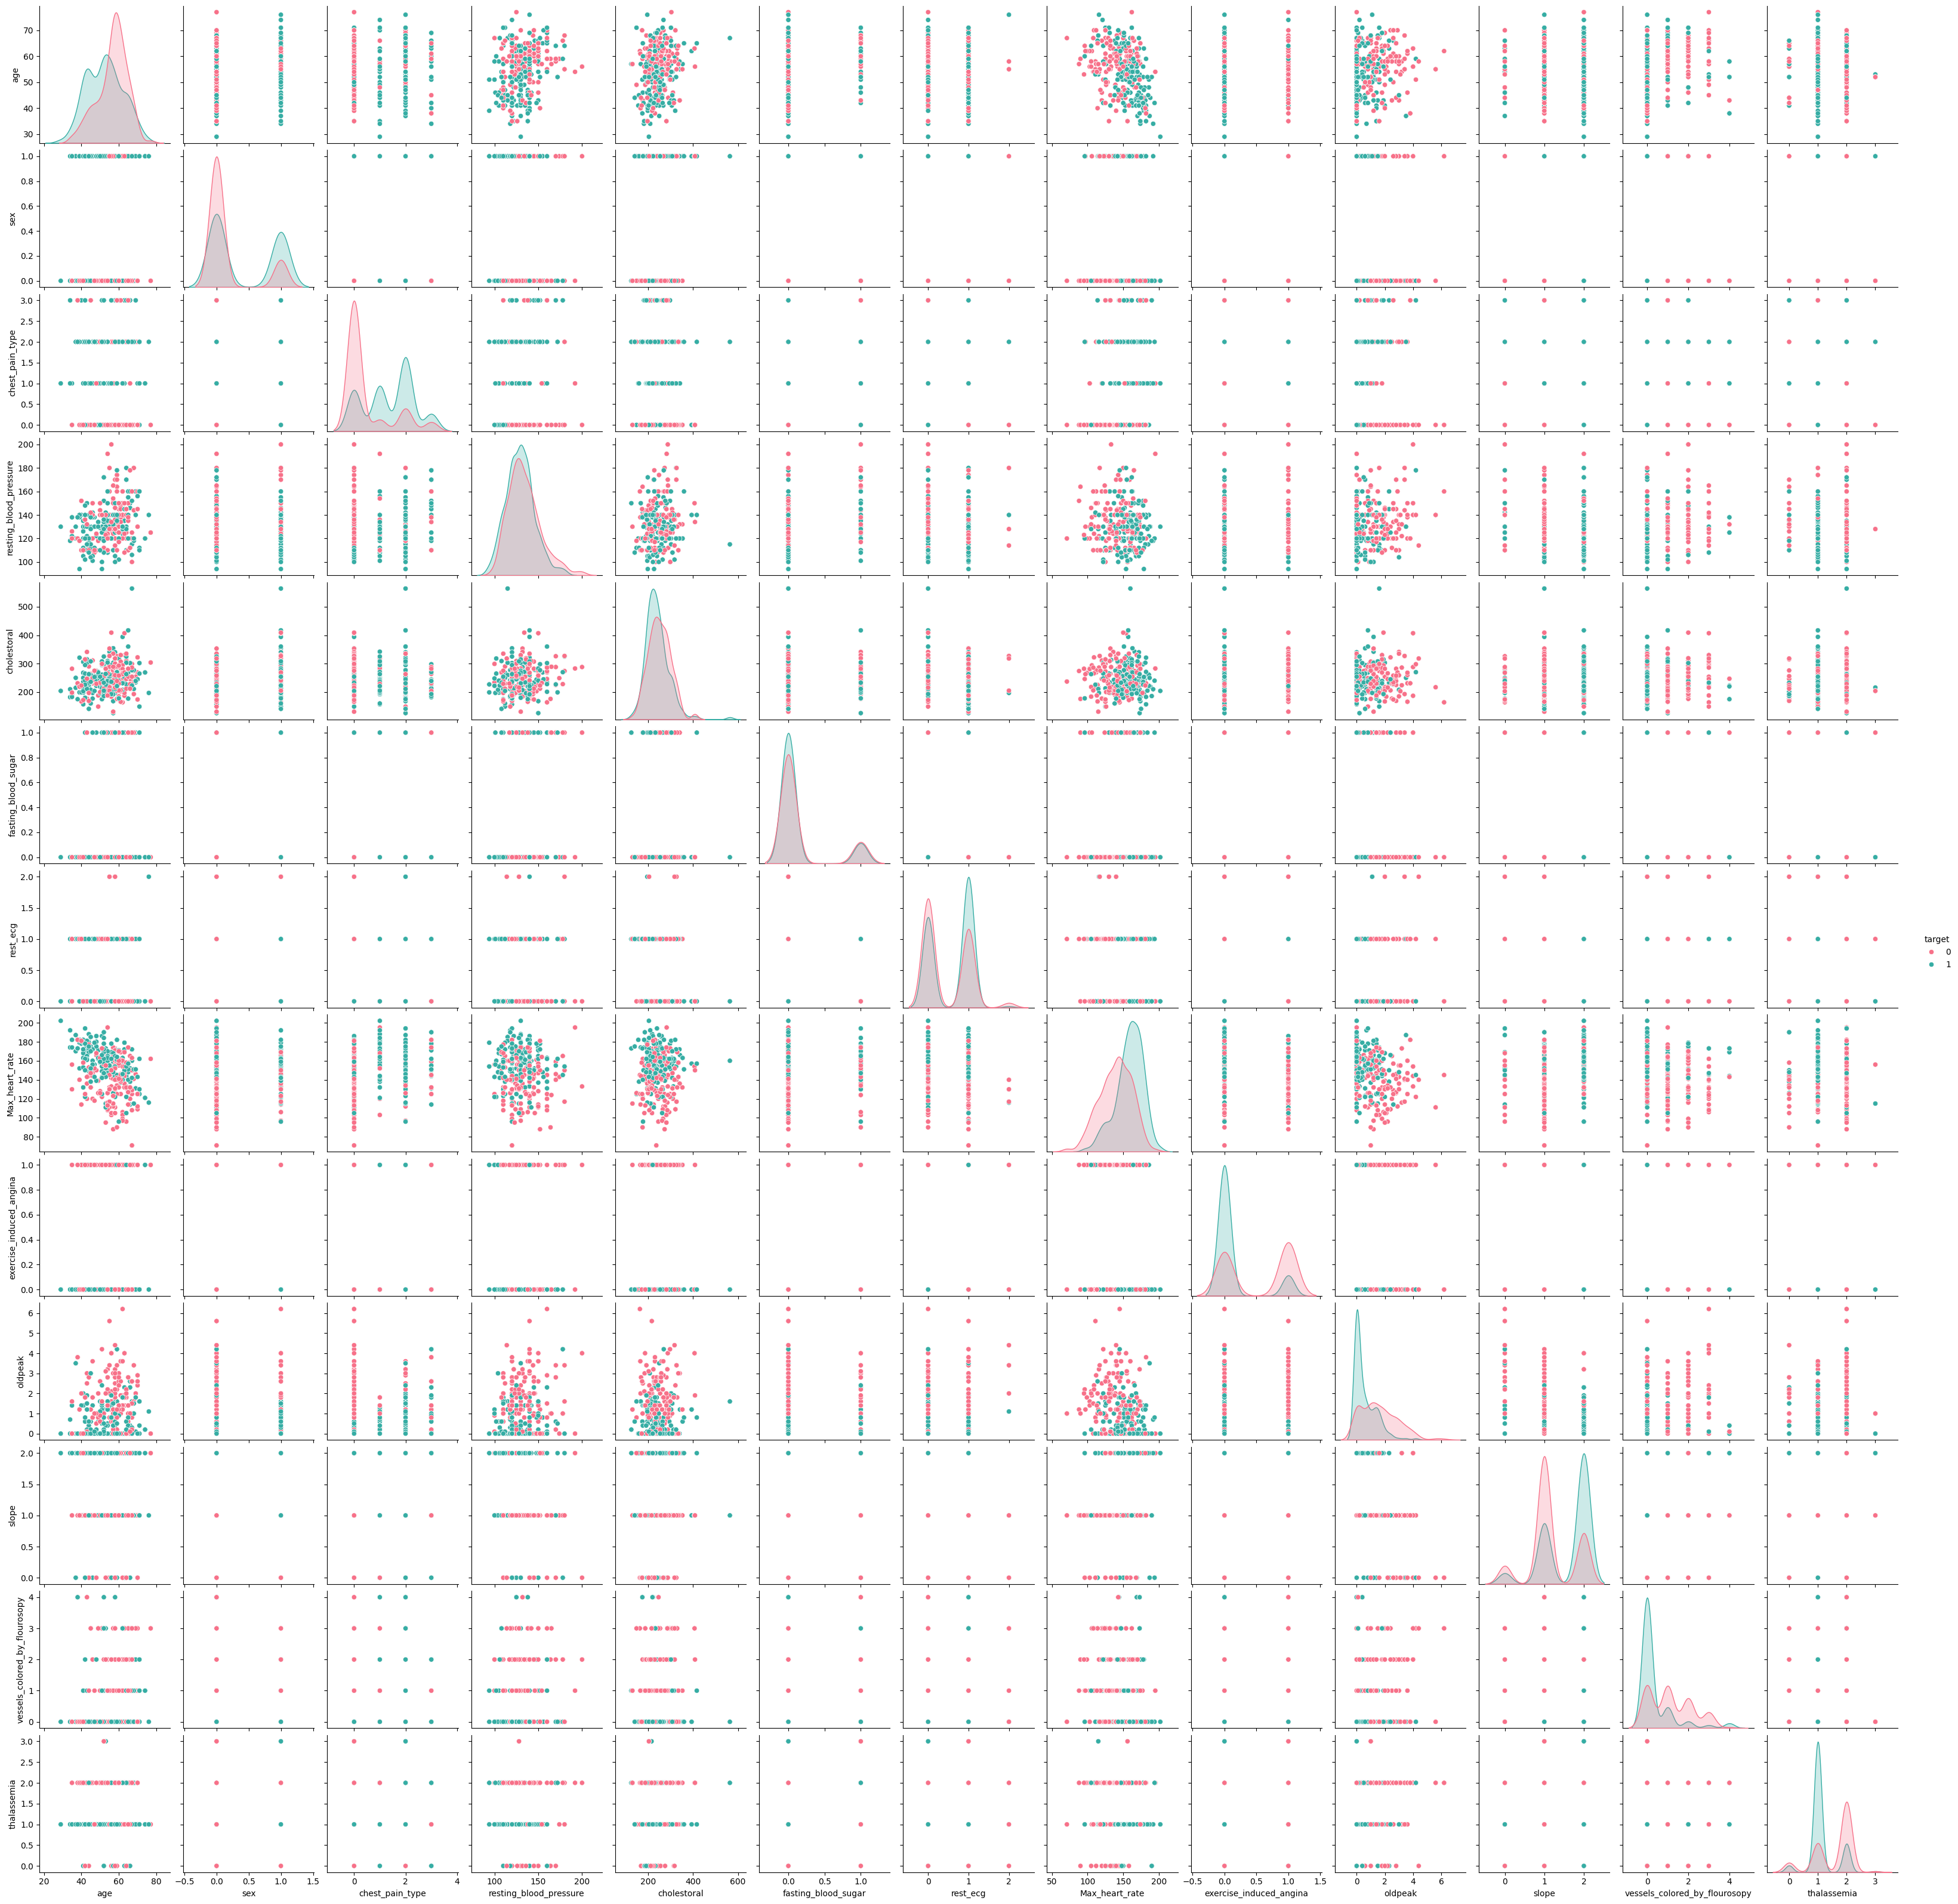

In [49]:
sns.pairplot(numerical_cols, hue="target", palette="husl")
plt.show()

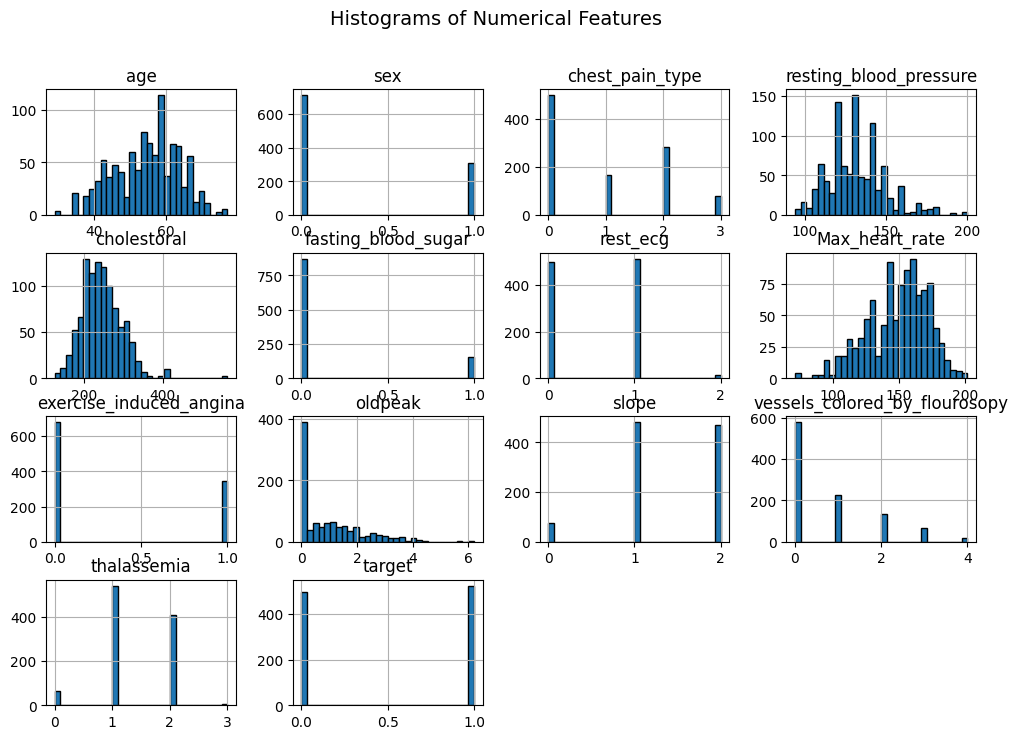

In [50]:
numerical_cols.hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.suptitle("Histograms of Numerical Features", fontsize=14)
plt.show()

## **Custom Charts**

In [51]:
import ipywidgets as widgets
from ipywidgets import interact
dd = widgets.Dropdown (
    options = ['age',	'sex',	'chest_pain_type',	'resting_blood_pressure',	'cholestoral',	'fasting_blood_sugar',	'rest_ecg',	'Max_heart_rate',	'exercise_induced_angina',	'oldpeak',	'slope',	'vessels_colored_by_flourosopy',	'thalassemia', 'target'],
    value = 'target',
    description = 'Select a column:',
)
def draw_countplot(column):
    p=sns.countplot(x=column, data=df)
    if len (df[column].unique()) > 4:
      p.tick_params(axis='x', rotation=90)

interact(draw_countplot, column=dd)

interactive(children=(Dropdown(description='Select a column:', index=13, options=('age', 'sex', 'chest_pain_ty…

<function __main__.draw_countplot(column)>

In [52]:
dd1 = widgets.Dropdown (
    options = ['age',	'sex',	'chest_pain_type',	'resting_blood_pressure',	'cholestoral',	'fasting_blood_sugar',	'rest_ecg',	'Max_heart_rate',	'exercise_induced_angina',	'oldpeak',	'slope',	'vessels_colored_by_flourosopy',	'thalassemia', 'target'],
    value = 'age',
    description = 'Column',
)
dd2 = widgets.Dropdown (
    options = ['age',	'sex',	'chest_pain_type',	'resting_blood_pressure',	'cholestoral',	'fasting_blood_sugar',	'rest_ecg',	'Max_heart_rate',	'exercise_induced_angina',	'oldpeak',	'slope',	'vessels_colored_by_flourosopy',	'thalassemia', 'target'],
    value = 'target',
    description = 'Hue',
)
ui = widgets.HBox([dd1, dd2])
def draw_countplot1(column, hue):
    p=sns.countplot(x=column, data=df, hue=hue)
    if len (df[column].unique()) > 4:
      p.tick_params(axis='x', rotation=90)

out = widgets.interactive_output(draw_countplot1, {'column':dd1, 'hue':dd2})
display(ui, out)

Output()

In [53]:
dd1 = widgets.Dropdown (
    options = ['age',	'sex',	'chest_pain_type',	'resting_blood_pressure',	'cholestoral',	'fasting_blood_sugar',	'rest_ecg',	'Max_heart_rate',	'exercise_induced_angina',	'oldpeak',	'slope',	'vessels_colored_by_flourosopy',	'thalassemia', 'target'],
    value = 'age',
    description = 'Column1',
)
dd2 = widgets.Dropdown (
    options = ['age',	'sex',	'chest_pain_type',	'resting_blood_pressure',	'cholestoral',	'fasting_blood_sugar',	'rest_ecg',	'Max_heart_rate',	'exercise_induced_angina',	'oldpeak',	'slope',	'vessels_colored_by_flourosopy',	'thalassemia', 'target'],
    value = 'sex',
    description = 'Column2',
)
dd3 = widgets.Dropdown (
    options = ['age',	'sex',	'chest_pain_type',	'resting_blood_pressure',	'cholestoral',	'fasting_blood_sugar',	'rest_ecg',	'Max_heart_rate',	'exercise_induced_angina',	'oldpeak',	'slope',	'vessels_colored_by_flourosopy',	'thalassemia', 'target'],
    value = 'target',
    description = 'Hue',
)
ui = widgets.HBox([dd1, dd2, dd3])
def draw_countplot2(column1, column2, hue):
    p=sns.relplot(x=column1, y=column2, data=df, hue=hue)

out = widgets.interactive_output(draw_countplot2, {'column1':dd1, 'column2':dd2, 'hue':dd3})
display(ui, out)

Output()

## **Feature Engineering**

**Feature Selection**

Chi-Square Test for Categorical Features

In [54]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode categorical variables
df_encoded = df.copy()
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])
x
# Chi-square test
chi_scores, p_values = chi2(df_encoded[categorical_cols], df_encoded['target'])
chi_results = pd.DataFrame({'Feature': categorical_cols, 'Chi-Square Score': chi_scores, 'p-value': p_values})
print(chi_results.sort_values(by='Chi-Square Score', ascending=False))


NameError: name 'x' is not defined

last two can be skipped as p > 0.05

Recursive Feature Elimination (RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Initialize model
model = RandomForestClassifier()
rfe = RFE(model, n_features_to_select=8)  # Select top 8 features

# Fit RFE
rfe.fit(df.drop(columns=['target']), df['target'])

# Show selected features
selected_features = df.drop(columns=['target']).columns[rfe.support_]
print("Selected Features:", selected_features)


**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical columns for scaling
cols_to_scale = ['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'oldpeak']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


# **Model selection and training**

Spliting Data

In [ ]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target variable (y)
X = df.drop(columns=['target'])  # Features
y = df['target']  # Target

# Step 1: Split Train (80%) and Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Step 2: Split Temp (20%) into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Display dataset shapes
print(f"Train Set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Validation Set: X_val = {X_val.shape}, y_val = {y_val.shape}")
print(f"Test Set: X_test = {X_test.shape}, y_test = {y_test.shape}")

 Train Models & Compare Performance

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- SVM
- K-Nearest Neighbors
- Naive Bayes


In [ ]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

# Train and evaluate models
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_val)  # Predict on validation set
    acc = accuracy_score(y_val, y_pred)  # Calculate accuracy
    accuracy_scores[name] = acc  # Store accuracy

# Display accuracy scores
for model, acc in accuracy_scores.items():
    print(f"{model}: {acc:.4f}")


# **Model Evaluation and hypertuning**

## **Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Store final evaluation metrics
final_metrics = []

# Dictionary to store confusion matrices and ROC data
conf_matrices = {}
roc_data = {}

# Re-train and evaluate models on Test Set
for name, model in models.items():
    model.fit(X_train, y_train)  # Train on full training set
    y_test_pred = model.predict(X_test)  # Predict on test set
    y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None  # Probabilities for ROC

    # Compute Metrics
    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    auc_roc = roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None

    # Store metrics in list
    final_metrics.append([name, accuracy, precision, recall, f1, auc_roc])

    # Store confusion matrix
    conf_matrices[name] = confusion_matrix(y_test, y_test_pred)

    # Store ROC curve data
    if y_test_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_prob)
        roc_data[name] = (fpr, tpr)

    # Print Classification Report
    print(f"\n🔹 Classification Report for {name} on Test Set:\n")
    print(classification_report(y_test, y_test_pred, target_names=["No Disease", "Disease"]))

# Convert final metrics list to DataFrame
final_metrics_df = pd.DataFrame(final_metrics, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"])

# Display comparison table
print("\n📌 Final Model Performance on Test Set:\n")
print(final_metrics_df)

# Plot Confusion Matrices
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"], ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# Plot ROC Curves
plt.figure(figsize=(10, 6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_test_prob):.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal line for reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


Loss calculation

In [ ]:
from sklearn.metrics import log_loss, hinge_loss

# Dictionary to store loss values
loss_values = {}

for name, model in models.items():
    y_test_pred = model.predict(X_test)  # Predicted class labels
    y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None  # Probabilities if available

    # Compute Log Loss for models that support probability predictions
    if y_test_prob is not None:
        loss = log_loss(y_test, y_test_prob)
        loss_values[name] = loss
    # Compute Hinge Loss for SVM (since it doesn't output probabilities)
    elif isinstance(model, SVC):
        loss = hinge_loss(y_test, y_test_pred)
        loss_values[name] = loss
    else:
        loss_values[name] = "N/A"  # For models that don't support loss calculation

# Display Loss values
print("\n📌 Loss Function Values for Each Model:")
for model, loss in loss_values.items():
    print(f"{model}: {loss:.4f}" if isinstance(loss, float) else f"{model}: {loss}")


## **Hypertuning**

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define hyperparameter distribution
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}

# Initialize model
rf = RandomForestClassifier()

# Perform Randomized Search
random_search_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf,
                                      n_iter=20, cv=5, scoring='accuracy',
                                      n_jobs=-1, verbose=2, random_state=42)
random_search_rf.fit(X_train, y_train)

# Best hyperparameters
print("Best Parameters for Random Forest:", random_search_rf.best_params_)

# Best model
best_rf = random_search_rf.best_estimator_


In [ ]:
# Train the best model again on the full training set
best_rf.fit(X_train, y_train)

# Evaluate on test data
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = best_rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Gradiant Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Define hyperparameter distribution
param_dist_gb = {
    'n_estimators': randint(100, 300),
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': randint(3, 10),
    'subsample': [0.7, 0.8, 0.9]
}

# Initialize model
gb = GradientBoostingClassifier()

# Perform Randomized Search
random_search_gb = RandomizedSearchCV(gb, param_distributions=param_dist_gb,
                                      n_iter=10, cv=5, scoring='accuracy',
                                      n_jobs=-1, verbose=2, random_state=42)
random_search_gb.fit(X_train, y_train)

# Best hyperparameters
print("Best Parameters for Gradient Boosting:", random_search_gb.best_params_)

# Best model
best_gb = random_search_gb.best_estimator_


In [ ]:
best_gb.fit(X_train, y_train)
y_pred_gb = best_gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb))


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names (if using Pandas DataFrame)
feature_names = X_train.columns

# Get feature importances
feature_importance_rf = best_rf.feature_importances_
feature_importance_gb = best_gb.feature_importances_

# Plot for Random Forest
plt.figure(figsize=(10, 5))
plt.bar(feature_names, feature_importance_rf, color='blue')
plt.xticks(rotation=45)
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Random Forest")
plt.show()

# Plot for Gradient Boosting
plt.figure(figsize=(10, 5))
plt.bar(feature_names, feature_importance_gb, color='green')
plt.xticks(rotation=45)
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Gradient Boosting")
plt.show()


KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Define hyperparameter distribution
param_dist_knn = {
    'n_neighbors': randint(3, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize model
knn = KNeighborsClassifier()

# Perform Randomized Search
random_search_knn = RandomizedSearchCV(knn, param_distributions=param_dist_knn,
                                       n_iter=10, cv=5, scoring='accuracy',
                                       n_jobs=-1, verbose=2, random_state=42)
random_search_knn.fit(X_train, y_train)

# Best hyperparameters
print("Best Parameters for KNN:", random_search_knn.best_params_)

# Best model
best_knn = random_search_knn.best_estimator_


In [ ]:
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))


Loss after hypertuning

In [ ]:
from sklearn.metrics import log_loss

# Predict probabilities instead of class labels
y_pred_rf_proba = best_rf.predict_proba(X_test)
y_pred_gb_proba = best_gb.predict_proba(X_test)
y_pred_knn_proba = best_knn.predict_proba(X_test)

# Calculate log loss for each model
rf_loss = log_loss(y_test, y_pred_rf_proba)
gb_loss = log_loss(y_test, y_pred_gb_proba)
knn_loss = log_loss(y_test, y_pred_knn_proba)

# Print loss values
print(f"Random Forest Log Loss: {rf_loss:.4f}")
print(f"Gradient Boosting Log Loss: {gb_loss:.4f}")
print(f"K-Nearest Neighbors Log Loss: {knn_loss:.4f}")


ROC curve after hypertuning

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC for each fine-tuned model
models = {
    "Random Forest": best_rf,
    "Gradient Boosting": best_gb,
    "K-Nearest Neighbors": best_knn
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    # Get probability predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

    # Compute False Positive Rate, True Positive Rate, and AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # Plot ROC Curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Plot the 45-degree diagonal line (random model)
plt.plot([0, 1], [0, 1], 'k--', label="Random Model")

# Labels and Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Fine-Tuned Models")
plt.legend()
plt.show()


## **Detecting Overfitting**

Train - test accuracy comparision


In [ ]:
train_accuracies = {}
test_accuracies = {}

for name, model in models.items():
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    train_accuracies[name] = train_acc
    test_accuracies[name] = test_acc

    print(f"{name} - Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")


Cross-Validation Score

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores[name] = scores.mean()
    print(f"{name} - Cross-Validation Score: {scores.mean():.4f}")


AUC (Area Under Curve)

In [ ]:
from sklearn.metrics import roc_auc_score

auc_train_scores = {}
auc_test_scores = {}

for name, model in models.items():
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    auc_train_scores[name] = train_auc
    auc_test_scores[name] = test_auc

    print(f"{name} - Train AUC: {train_auc:.4f}, Test AUC: {test_auc:.4f}")


Loss Values

In [ ]:
from sklearn.metrics import log_loss

train_losses = {}
test_losses = {}

for name, model in models.items():
    train_loss = log_loss(y_train, model.predict_proba(X_train))
    test_loss = log_loss(y_test, model.predict_proba(X_test))

    train_losses[name] = train_loss
    test_losses[name] = test_loss

    print(f"{name} - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")
